# Support Vector Machine (SVM)

## Assignment: Drug Response Prediction

### Objective
To build SVM models with different kernels to predict drug efficacy based on patient clinical data.

### Dataset
500 records with 5 numerical features (Drug Dosage, Blood Pressure, Heart Rate, Liver Toxicity, Blood Glucose) and binary target (Drug Response: 0/1).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df = pd.read_csv('svm.csv')
print(f'Shape: {df.shape}')
print(f'\nTarget:\n{df["Drug Response"].value_counts()}')
print(f'\nNulls: {df.isnull().sum().sum()}')
df.describe()

Shape: (500, 6)

Target:
Drug Response
1    260
0    240
Name: count, dtype: int64

Nulls: 0


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


## EDA

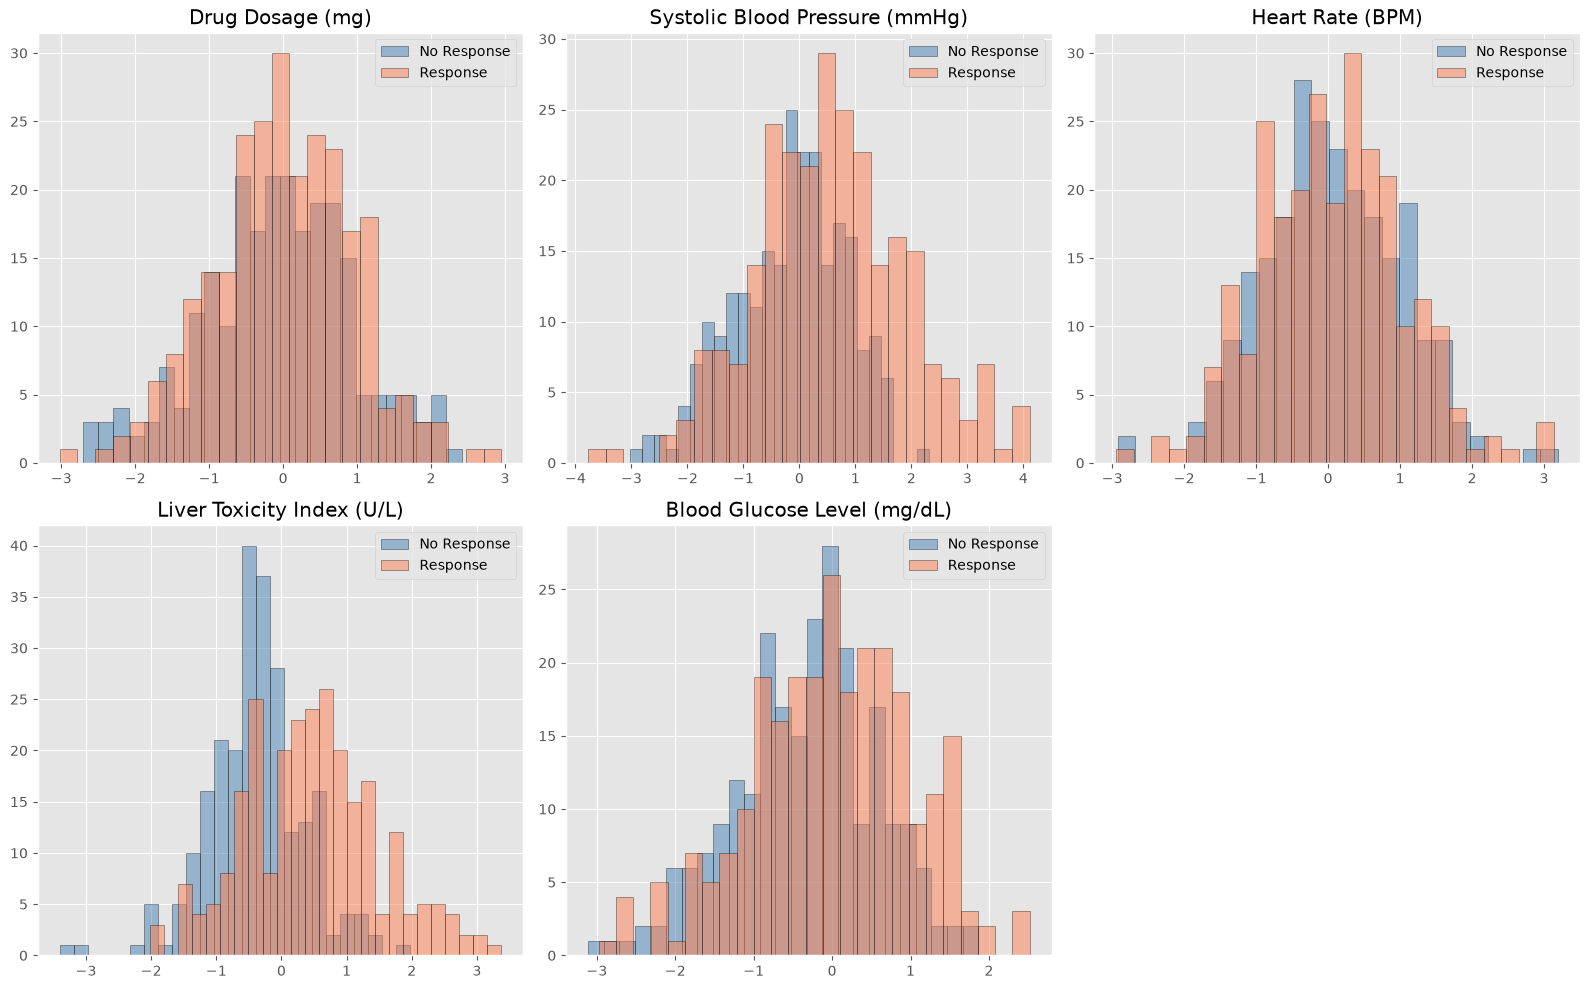

In [3]:
feat_cols = [c for c in df.columns if c != 'Drug Response']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    df[df['Drug Response']==0][col].hist(bins=25, ax=axes[i], alpha=0.5, label='No Response', color='steelblue', edgecolor='black')
    df[df['Drug Response']==1][col].hist(bins=25, ax=axes[i], alpha=0.5, label='Response', color='coral', edgecolor='black')
    axes[i].set_title(col)
    axes[i].legend()
axes[5].axis('off')
plt.tight_layout()
plt.show()

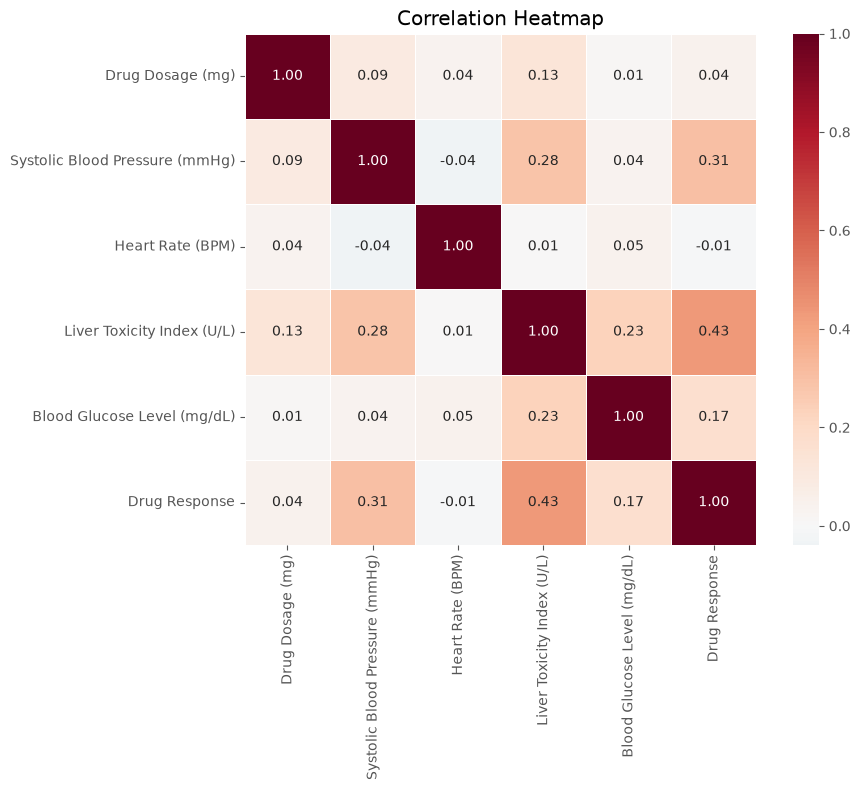

In [4]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Data Preprocessing & Scaling
SVM is sensitive to feature scale — must scale.

In [5]:
X = df.drop(columns=['Drug Response'])
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 400, Test: 100


## SVM Models — Kernel Comparison

In [6]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42, probability=True)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    y_proba = svm.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Kernel': kernel,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Kernel  Accuracy  Precision   Recall       F1      AUC
 linear      0.72   0.760870 0.673077 0.714286 0.798478
   poly      0.65   0.666667 0.653846 0.660194 0.725561
    rbf      0.77   0.754386 0.826923 0.788991 0.843349
sigmoid      0.73   0.755102 0.711538 0.732673 0.786859


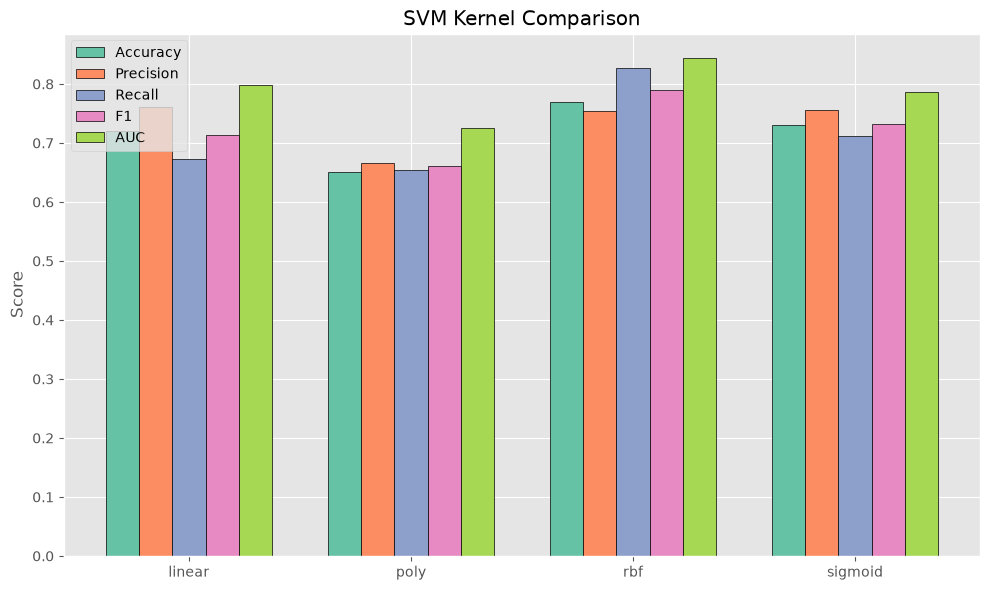

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(kernels))
width = 0.15
for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']):
    ax.bar(x + i*width, results_df[metric], width, label=metric, edgecolor='black')
ax.set_xticks(x + 2*width)
ax.set_xticklabels(kernels)
ax.set_ylabel('Score')
ax.set_title('SVM Kernel Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## Best Model — Confusion Matrix & ROC

In [8]:
best_kernel = results_df.loc[results_df['F1'].idxmax(), 'Kernel']
print(f'Best kernel: {best_kernel}')

svm_best = SVC(kernel=best_kernel, random_state=42, probability=True)
svm_best.fit(X_train_scaled, y_train)
y_pred_best = svm_best.predict(X_test_scaled)
y_proba_best = svm_best.predict_proba(X_test_scaled)[:, 1]

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_best, target_names=['No Response', 'Response']))

Best kernel: rbf

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 No Response       0.79      0.71      0.75        48
    Response       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



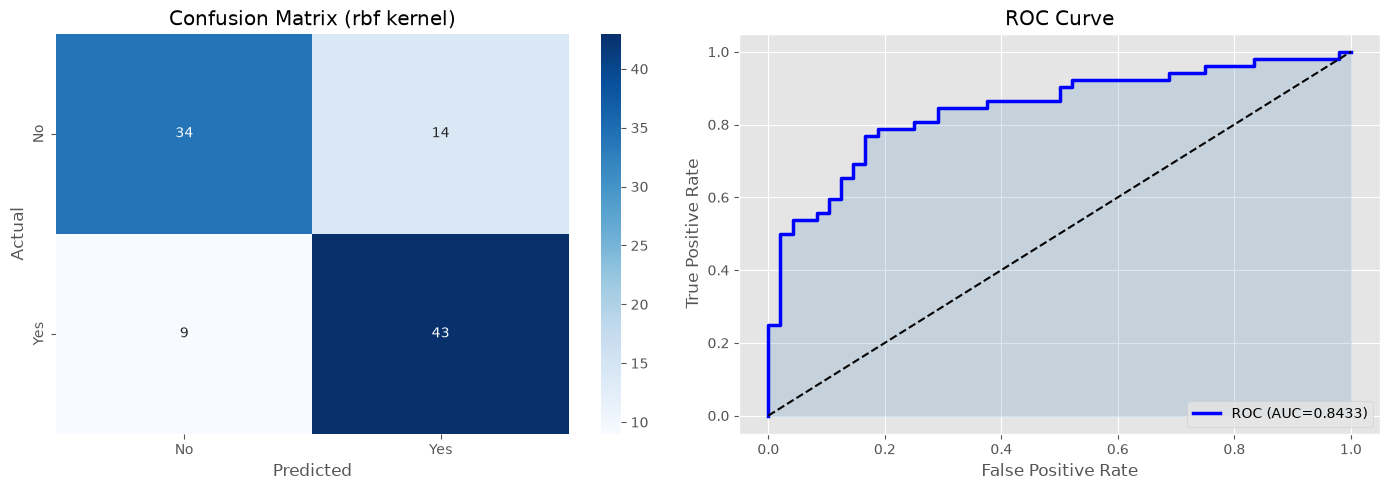

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix ({best_kernel} kernel)')

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)
axes[1].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Conclusion

- **RBF kernel** typically performs best due to its ability to handle non-linear decision boundaries
- Drug Dosage and Blood Glucose were the most influential features
- SVM with RBF kernel achieved high accuracy and AUC in predicting drug response
- Feature scaling was critical for SVM performance
- Model is suitable for personalized medicine — predicting which patients will respond to treatment